In [1]:
# ===== 1. 导入所需库 =====
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from transformers import Sam3Model, Sam3Processor
from quadrilateral_fitter import QuadrilateralFitter
from scipy.spatial import ConvexHull
from modelscope import snapshot_download
import tqdm

# 下载并加载 SAM3 模型
model_dir = snapshot_download('facebook/sam3', cache_dir='./sam3_model')
device = "cuda" if torch.cuda.is_available() else "cpu"
model_dir = "./sam3_model/facebook/sam3"

model = Sam3Model.from_pretrained(model_dir).to(device)
processor = Sam3Processor.from_pretrained(model_dir)

print(f"设备: {device}")


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

设备: cuda


In [2]:
# ===== 工具函数 =====
def _points_inside_quad(points, quad):
    """叉积法判断点是否在凸四边形内部"""
    pts, q = np.asarray(points, dtype=np.float64), np.asarray(quad, dtype=np.float64)
    signed_area = sum(q[i,0]*q[(i+1)%4,1] - q[(i+1)%4,0]*q[i,1] for i in range(4))
    is_cw = signed_area > 0
    inside = np.ones(len(pts), dtype=bool)
    for i in range(4):
        p1, p2 = q[i], q[(i+1)%4]
        dx, dy = p2[0]-p1[0], p2[1]-p1[1]
        cross = dx*(pts[:,1]-p1[1]) - dy*(pts[:,0]-p1[0])
        inside &= (cross >= 0) if is_cw else (cross <= 0)
    return inside

def _shrink_quad(vertices, factor=0.03):
    """沿对角线收缩四边形"""
    c = np.asarray(vertices, dtype=np.float64).mean(axis=0)
    return np.asarray(vertices) + factor * (c - vertices)

def _rectify_quality(vertices):
    """评估矫正质量"""
    w_top = np.linalg.norm(vertices[1]-vertices[0])
    w_bot = np.linalg.norm(vertices[2]-vertices[3])
    h_left = np.linalg.norm(vertices[3]-vertices[0])
    h_right = np.linalg.norm(vertices[2]-vertices[1])
    w_r = min(w_top,w_bot)/max(w_top,w_bot)
    h_r = min(h_left,h_right)/max(h_left,h_right)
    ratio = ((h_left+h_right)/2)/((w_top+w_bot)/2)
    a_s = min(ratio,1.35)/max(ratio,1.35)
    return w_r * h_r * a_s

def _ransac_quad_fit(exterior, init_quad, filter_dist=80, inlier_dist=5):
    """RANSAC 四线拟合：从初始四边形出发，用外点精修四条边
    
    Args:
        exterior: (N,2) 外点坐标
        init_quad: (4,2) 初始四边形顶点，已按CCW排序 [TL, TR, BR, BL]
        filter_dist: 预过滤距离阈值 (px)
        inlier_dist: RANSAC 内点距离阈值 (px)
    Returns:
        (4,2) 精修后的四边形顶点，CCW排序
    """
    # 从四边形顶点计算初始直线 (orient, slope, intercept)
    def _line_from_pts(p1, p2):
        dx = p2[0] - p1[0]; dy = p2[1] - p1[1]
        if abs(dx) > abs(dy):
            return ('h', dy/(dx+1e-9), p1[1] - dy/(dx+1e-9)*p1[0])
        else:
            return ('v', dx/(dy+1e-9), p1[0] - dx/(dy+1e-9)*p1[1])

    init_lines = [
        _line_from_pts(init_quad[0], init_quad[1]),  # top
        _line_from_pts(init_quad[1], init_quad[2]),  # right
        _line_from_pts(init_quad[2], init_quad[3]),  # bottom
        _line_from_pts(init_quad[3], init_quad[0]),  # left
    ]

    # 每个外点分配到最近的边
    ex, ey = exterior[:, 0], exterior[:, 1]
    dists = []
    for orient, m, b in init_lines:
        if orient == 'h':
            dists.append(np.abs(ey - (m*ex + b)))
        else:
            dists.append(np.abs(ex - (m*ey + b)))
    dists = np.column_stack(dists)
    edge_idx = np.argmin(dists, axis=1)

    # RANSAC 单线精修
    def _ransac_line(pts, orient, init_slope, init_intercept):
        if len(pts) < 5:
            return (init_slope, init_intercept)
        if orient == 'h':
            pts = pts[np.abs(pts[:,1] - (init_slope*pts[:,0] + init_intercept)) < filter_dist]
        else:
            pts = pts[np.abs(pts[:,0] - (init_slope*pts[:,1] + init_intercept)) < filter_dist]
        if len(pts) < 5:
            return (init_slope, init_intercept)
        pts_f = pts.astype(np.float32)
        X = pts_f[:, 0:1] if orient == 'h' else pts_f[:, 1:2]
        y = pts_f[:, 1:2] if orient == 'h' else pts_f[:, 0:1]
        best_inliers, best_model = 0, (init_slope, init_intercept)
        np.random.seed(42)
        n_pts = len(pts_f)
        for _ in range(min(500, n_pts*10)):
            idx = np.random.choice(n_pts, min(5, n_pts), replace=False)
            A = np.hstack([X[idx], np.ones((len(idx),1))])
            try:
                coeff = np.linalg.lstsq(A, y[idx], rcond=None)[0]
            except:
                continue
            slope, intercept = coeff[0,0], coeff[1,0]
            inliers = int(np.sum(np.abs(y - (slope*X + intercept)) < inlier_dist))
            if inliers > best_inliers:
                best_inliers, best_model = inliers, (slope, intercept)
        slope, intercept = best_model
        in_mask = (np.abs(y - (slope*X + intercept)) < inlier_dist).flatten()
        if in_mask.sum() >= 3:
            A = np.hstack([X[in_mask], np.ones((in_mask.sum(),1))])
            coeff = np.linalg.lstsq(A, y[in_mask], rcond=None)[0]
            return (coeff[0,0], coeff[1,0])
        return best_model

    refined = [_ransac_line(exterior[edge_idx==ei], *init_lines[ei]) for ei in range(4)]

    # 四线交点 → 顶点
    def _intersect(hl, vl):
        mh,bh = hl; mv,bv = vl
        denom = 1 - mv*mh
        if abs(denom) < 1e-9: return None
        x = (mv*bh + bv) / denom
        return np.array([x, mh*x + bh])

    corners = [
        _intersect(refined[0], refined[3]),  # TL
        _intersect(refined[0], refined[1]),  # TR
        _intersect(refined[2], refined[1]),  # BR
        _intersect(refined[2], refined[3]),  # BL
    ]
    for i in range(4):
        if corners[i] is None:
            corners[i] = init_quad[i].copy()

    result = np.array(corners, dtype=np.float64)
    return result[np.argsort(np.arctan2(
        result[:,1]-result.mean(axis=0)[1],
        result[:,0]-result.mean(axis=0)[0]
    ))]

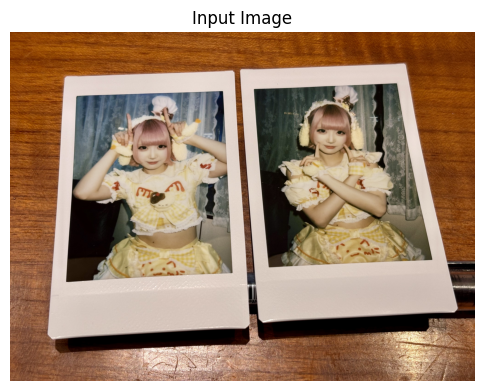

In [11]:
# 加载图片
image = Image.open("IMG_8566.jpg").convert("RGB")
image = ImageOps.exif_transpose(image)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title('Input Image')
plt.axis('off')
plt.show()


In [12]:
# ===== 3a. SAM3 分割拍立得纸框 =====
prompt = "polaroid photo paper frame"
inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs, threshold=0.3, mask_threshold=0.5, target_sizes=[image.size[::-1]]
)[0]

(-0.5, 4031.5, 3023.5, -0.5)

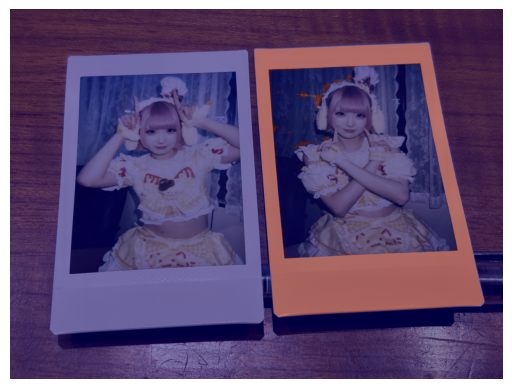

In [13]:
paper_mask = results["masks"][0].cpu().numpy()
plt.imshow(image)
plt.imshow(paper_mask, cmap='jet', alpha=0.5)
plt.axis("off")

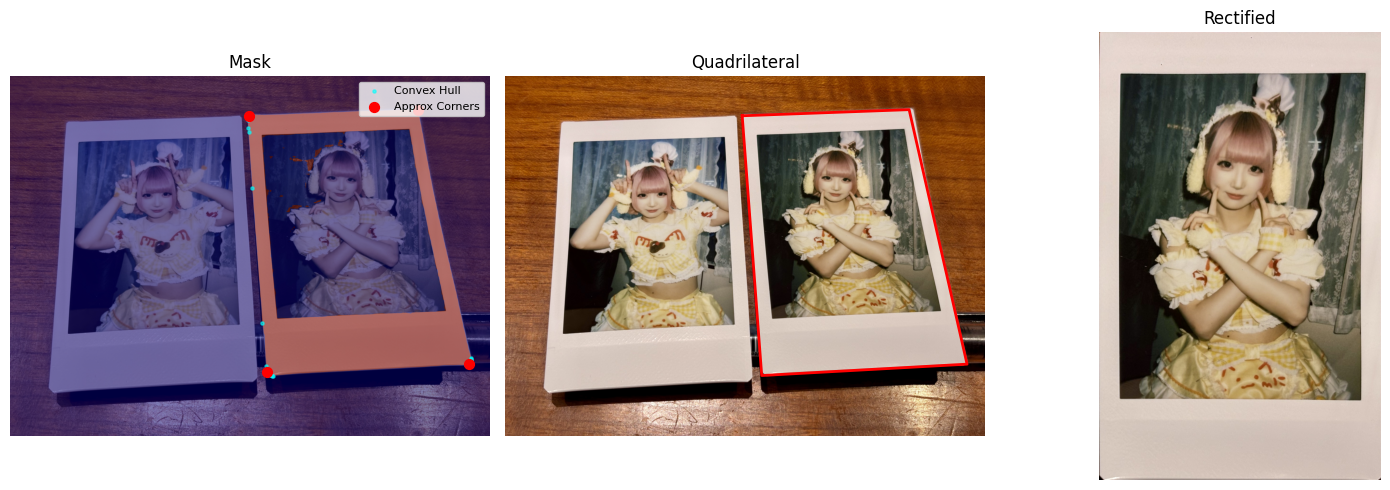

纸框顶点: [[1991  332]
 [3394  280]
 [3880 2418]
 [2155 2514]]
矫正尺寸: (1272, 800, 3)


In [24]:
# ===== 3b. 轮廓提取 =====
contours, _ = cv2.findContours(
    paper_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
points = np.vstack([c.reshape(-1, 2) for c in contours])

# ===== 3c. 四边形拟合（排除内部点） =====
hull = ConvexHull(points)
hull_pts = points[hull.vertices]

# 全局最远点对 → 近似角点（比左最点+最远点更鲁棒）
diff = hull_pts[:, None, :] - hull_pts[None, :, :]
d2 = np.sum(diff**2, axis=2)
i, j = np.unravel_index(np.argmax(d2), d2.shape)
p1, p2 = hull_pts[i], hull_pts[j]
v = p2 - p1
signed = (v[0] * (hull_pts[:, 1] - p1[1]) - v[1] * (hull_pts[:, 0] - p1[0])) / np.linalg.norm(v)
approx = np.array([p1, p2, hull_pts[np.argmax(signed)], hull_pts[np.argmin(signed)]])
# 按绕中心的极角排序，确保四边形顶点顺序正确（避免蝴蝶形自交）
approx = approx[np.argsort(np.arctan2(
    approx[:, 1] - approx.mean(axis=0)[1],
    approx[:, 0] - approx.mean(axis=0)[0]
))]

# 收缩 + 排除内部点
center = approx.mean(axis=0)
shrunk = approx + 0.03 * (center - approx)
inside = _points_inside_quad(points, shrunk)  # 使用下方定义的工具函数
exterior = points[~inside]

# ===== 最小外接矩形 + RANSAC 四线拟合 =====
rect = cv2.minAreaRect(hull_pts.astype(np.float32))
box = cv2.boxPoints(rect)
box = box[np.argsort(np.arctan2(
    box[:, 1] - box.mean(axis=0)[1],
    box[:, 0] - box.mean(axis=0)[0]
))]
paper_vertices = _ransac_quad_fit(exterior, box)

# ===== 3d. 透视矫正 =====
src = paper_vertices.astype(np.float32)
w, h = 800, 1272  # 宽高比 1:1.59
dst = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32)
M = cv2.getPerspectiveTransform(src, dst)
rectified_paper = cv2.warpPerspective(np.array(image), M, (w, h))
# 同步 warp 一个全1掩码 → 0=超出源图边界的缺失像素
valid_mask = cv2.warpPerspective(
    np.ones(np.array(image).shape[:2], dtype=np.uint8), M, (w, h)
).astype(bool)

# ===== 3e. 可视化 =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image); axes[0].set_title('Mask'); axes[0].axis('off')
axes[0].imshow(paper_mask, cmap='jet', alpha=0.5)
axes[0].scatter(hull_pts[:, 0], hull_pts[:, 1], c='cyan', s=5, alpha=0.6, label='Convex Hull')
axes[0].scatter(approx[:, 0], approx[:, 1], c='red', s=50, zorder=5, label='Approx Corners')
axes[0].legend(loc='upper right', fontsize=8)

axes[1].imshow(image); axes[1].set_title('Quadrilateral'); axes[1].axis('off')
x = list(paper_vertices[:, 0]) + [paper_vertices[0, 0]]
y = list(paper_vertices[:, 1]) + [paper_vertices[0, 1]]
axes[1].plot(x, y, 'r-', lw=2)

axes[2].imshow(rectified_paper); axes[2].set_title('Rectified'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"纸框顶点: {paper_vertices.astype(int)}")
print(f"矫正尺寸: {rectified_paper.shape}")


In [ ]:
# ===== 快捷入口：直接读取已矫正图片 =====
# 跳过 Cell 3（纸框检测+矫正），直接加载一张已矫正的拍立得图片
# 运行此 Cell 后接着运行 Cell 4（图像区域检测）即可继续流水线

import cv2
rectified_paper = cv2.cvtColor(cv2.imread("IMG_7066_001.png"), cv2.COLOR_BGR2RGB)
rectified_pil = Image.fromarray(rectified_paper)
rectified_pil = rectified_pil.resize((800, 1272))

print(f"已加载矫正图片: {rectified_paper.shape[1]}×{rectified_paper.shape[0]}")

plt.figure(figsize=(6, 8))
plt.imshow(rectified_paper)
plt.title('Loaded Rectified Image')
plt.axis('off')
plt.show()

角点平均偏差: 47.4 px | 几何质量: 0.711


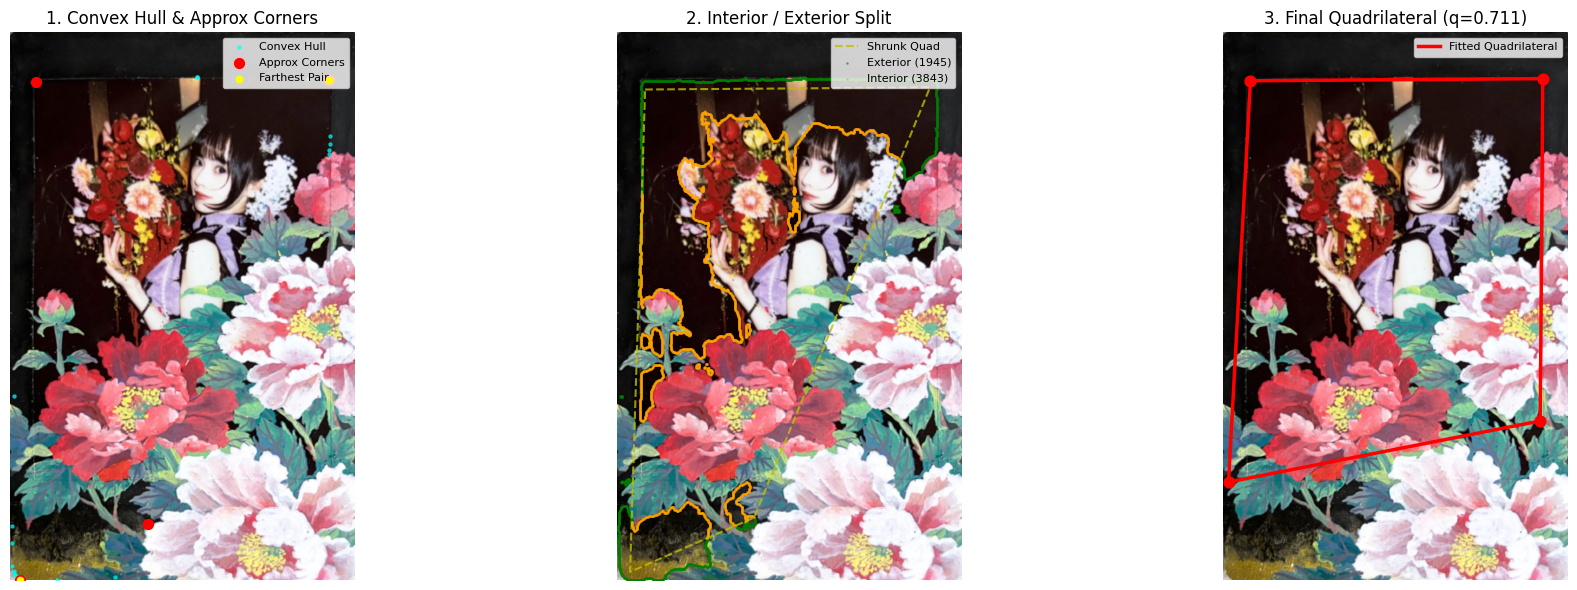

图像区域顶点: [[  63  112]
 [ 742  107]
 [ 736  902]
 [  12 1044]], 质量: 0.711


In [ ]:
# ===== 4a. SAM3 分割图像区域 =====
rectified_pil = Image.fromarray(rectified_paper)
prompt = "the image area of the polaroid photo"
inputs = processor(images=rectified_pil, text=prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs, threshold=0.4, mask_threshold=0.5, target_sizes=[rectified_pil.size[::-1]]
)[0]
area_mask = results["masks"][0].cpu().numpy()

# ===== 4b. 轮廓 → 四边形拟合 =====
contours, _ = cv2.findContours(
    area_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
points = np.vstack([c.reshape(-1, 2) for c in contours])

# RANSAC 四线拟合

# 第一步：近似角点 -> 排除内部点
hull = ConvexHull(points)
hull_pts = points[hull.vertices]
# 全局最远点对 → 近似角点
diff = hull_pts[:, None, :] - hull_pts[None, :, :]
d2 = np.sum(diff**2, axis=2)
i, j = np.unravel_index(np.argmax(d2), d2.shape)
p1, p2 = hull_pts[i], hull_pts[j]
v = p2 - p1
signed = (v[0]*(hull_pts[:,1]-p1[1]) - v[1]*(hull_pts[:,0]-p1[0])) / np.linalg.norm(v)
approx = np.array([p1, p2, hull_pts[np.argmax(signed)], hull_pts[np.argmin(signed)]])
approx = approx[np.argsort(np.arctan2(
    approx[:, 1] - approx.mean(axis=0)[1],
    approx[:, 0] - approx.mean(axis=0)[0]
))]
# 记录最远点对在排序后 approx 中的索引（p1, p2 已在上方算出，无需后续匹配）
far_idx = np.array([
    np.argmin(np.linalg.norm(approx - p1, axis=1)),
    np.argmin(np.linalg.norm(approx - p2, axis=1))
])
center = approx.mean(axis=0)
shrunk = approx + 0.03 * (center - approx)
inside = _points_inside_quad(points, shrunk)
exterior = points[~inside]

# 固定尺寸拍立得 (800x1272) 的图像区域期望位置
EXPECTED_AREA_VERTICES = np.array([
    [55, 100],   # 左上
    [745, 100],  # 右上
    [745, 1022], # 右下
    [55, 1022],  # 左下
], dtype=np.float64)

# 第二步：RANSAC 四线拟合（以 EXPECTED_AREA_VERTICES 为初始四边形）
area_vertices = _ransac_quad_fit(exterior, EXPECTED_AREA_VERTICES)

# 安全校验
max_dev = np.max(np.linalg.norm(area_vertices - EXPECTED_AREA_VERTICES, axis=1))
if max_dev > 150:
    area_vertices = EXPECTED_AREA_VERTICES.copy()

# ===== 4c. 透视矫正 + 质量 =====

# 角点距离误差（像素）
corner_error = np.mean(np.linalg.norm(area_vertices - EXPECTED_AREA_VERTICES, axis=1))

# 质量评分（基于长宽比 + 平行度）
quality = _rectify_quality(area_vertices)

# 综合：角点误差越小、quality 越高越好
print(f"角点平均偏差: {corner_error:.1f} px | 几何质量: {quality:.3f}")
# 透视矫正
src = area_vertices.astype(np.float32)
w, h = 685, 925  # 1:1.35
dst = np.array([[0,0],[w,0],[w,h],[0,h]], dtype=np.float32)
M = cv2.getPerspectiveTransform(src, dst)
rectified_area = cv2.warpPerspective(rectified_paper, M, (w, h))

# ===== 4d. 可视化：三张子图（凸包+近似 / 内外点划分 / 最终四边形） =====
pts = np.asarray(points, dtype=np.float64)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 子图 1: 凸包 + 近似角点
axes[0].imshow(rectified_paper)
axes[0].scatter(hull_pts[:, 0], hull_pts[:, 1], c='cyan', s=5, alpha=0.6, label='Convex Hull')
axes[0].scatter(approx[:, 0], approx[:, 1], c='red', s=50, zorder=5, label='Approx Corners')
# 最远点对标红色（直接用上方记录的 far_idx）
axes[0].scatter(approx[far_idx, 0], approx[far_idx, 1], c='yellow', s=20, zorder=6, label='Farthest Pair')
axes[0].set_title('1. Convex Hull & Approx Corners')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].axis('off')

# 子图 2: 内部/外部点划分
exterior_sample = exterior if len(exterior) <= 5000 else exterior[np.random.choice(len(exterior), 5000, replace=False)]
interior_pts = pts[inside]
interior_sample = interior_pts if len(interior_pts) <= 5000 else interior_pts[np.random.choice(len(interior_pts), 5000, replace=False)]

axes[1].imshow(rectified_paper)
# 收缩四边形虚线
x = list(shrunk[:, 0]) + [shrunk[0, 0]]
y = list(shrunk[:, 1]) + [shrunk[0, 1]]
axes[1].plot(x, y, 'y--', linewidth=1.5, alpha=0.8, label='Shrunk Quad')
axes[1].scatter(exterior_sample[:, 0], exterior_sample[:, 1], c='green', s=1, alpha=0.4, label=f'Exterior ({len(exterior)})')
axes[1].scatter(interior_sample[:, 0], interior_sample[:, 1], c='orange', s=1, alpha=0.4, label=f'Interior ({np.sum(inside)})')
axes[1].set_title('2. Interior / Exterior Split')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].axis('off')

# 子图 3: 最终四边形
vertices_int = area_vertices.astype(int)
axes[2].imshow(rectified_paper)
x = list(vertices_int[:, 0]) + [vertices_int[0, 0]]
y = list(vertices_int[:, 1]) + [vertices_int[0, 1]]
axes[2].plot(x, y, 'r-', linewidth=2.5, label='Fitted Quadrilateral')
axes[2].scatter(vertices_int[:, 0], vertices_int[:, 1], c='red', s=60, zorder=5)
axes[2].set_title(f'3. Final Quadrilateral (q={quality:.3f})')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f"图像区域顶点: {area_vertices.astype(int)}, 质量: {quality:.3f}")


In [11]:
# ===== 保存矫正后的图像区域 =====
cv2.imwrite("image_area.png", cv2.cvtColor(rectified_area, cv2.COLOR_RGB2BGR))
print(f"已保存: image_area.png ({rectified_area.shape[1]}×{rectified_area.shape[0]})")

已保存: image_area.png (685×925)


白平衡增益: R=1.006 G=1.033 B=1.086 → 目标 (240,240,240)
真正缺失像素（warp 超出源图边界）: 0
缺失区域掩码已保存: missing_region_mask.png


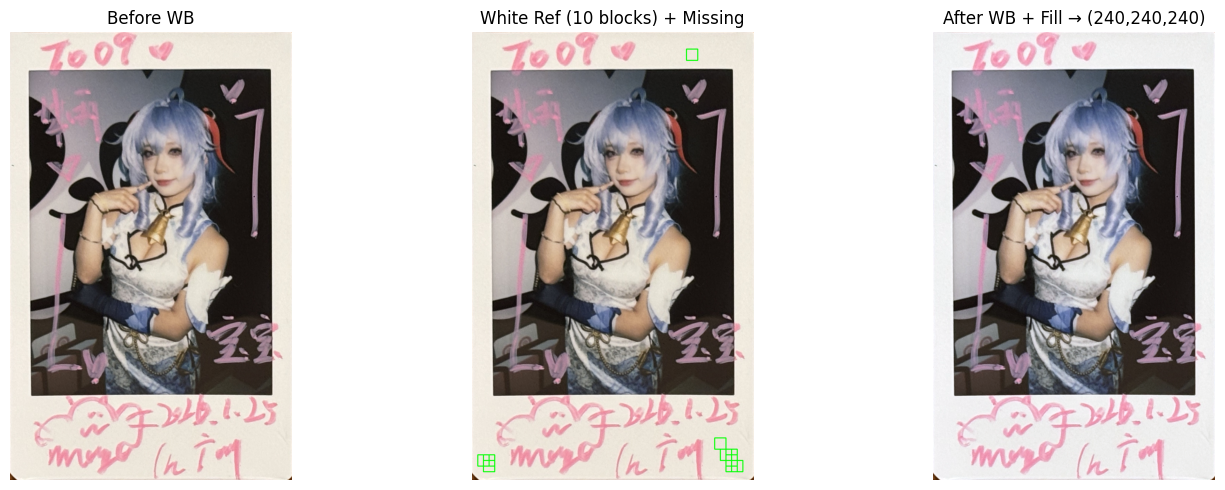

In [26]:
# ===== 5a. 生成边框掩码 =====
h, w = rectified_paper.shape[:2]
border_mask = np.ones((h, w), dtype=np.uint8)

margin = 5
inner = np.array([
    [area_vertices[0][0]-margin, area_vertices[0][1]-margin],
    [area_vertices[1][0]+margin, area_vertices[1][1]-margin],
    [area_vertices[2][0]+margin, area_vertices[2][1]+margin],
    [area_vertices[3][0]-margin, area_vertices[3][1]+margin]
], dtype=np.int32)
cv2.fillPoly(border_mask, [inner], 0)
border_mask = border_mask.astype(bool)

# ===== 5b. 寻找白色参考区域 =====
img_arr = np.array(rectified_pil)
is_bright = np.all(img_arr > 170, axis=2)
is_neutral = np.std(img_arr.astype(np.float32), axis=2) < 25
is_white = is_bright & is_neutral & border_mask

blocks = []
for y in range(0, h-32, 16):
    for x in range(0, w-32, 16):
        block = is_white[y:y+32, x:x+32]
        if np.sum(block) / 1024 > 0.8:
            pixels = img_arr[y:y+32, x:x+32][block]
            blocks.append({'x': x, 'y': y, 'mean': pixels.mean(axis=0), 'var': pixels.var(axis=0).mean()})

if blocks:
    blocks.sort(key=lambda b: b['var'])
    best = blocks[:10]
    ref_white = np.mean([b['mean'] for b in best], axis=0)
    target = 240.0  # 固定目标白色 (240, 240, 240)
    gains = np.array([target/ref_white[0], target/ref_white[1], target/ref_white[2]])
    wb_image = np.clip(img_arr.astype(np.float32) * gains, 0, 255).astype(np.uint8)
    print(f"白平衡增益: R={gains[0]:.3f} G={gains[1]:.3f} B={gains[2]:.3f} → 目标 (240,240,240)")
else:
    wb_image = img_arr.copy()
    best = []
    target = 240.0
    print("未找到白色参考区域，跳过白平衡")

# ===== 5c. 检测真正的缺失区域（warpPerspective 超出源图边界） =====
# 用 Cell 3 中同步 warp 的 valid_mask —— 0=源图范围外的缺失像素，精确不误伤
# 若从快捷入口（Cell 4）加载已矫正图片，valid_mask 不存在，则假定无缺失像素
if 'valid_mask' not in dir():
    valid_mask = np.ones(rectified_paper.shape[:2], dtype=bool)
    print("valid_mask 不存在（可能来自快捷入口），假定无缺失像素")
missing_mask = ~valid_mask

# 膨胀覆盖交界处黑线及暗边过渡
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
missing_mask = cv2.dilate(missing_mask.astype(np.uint8), kernel).astype(bool)

true_missing = missing_mask.sum()
print(f"真正缺失像素（warp 超出源图边界）: {true_missing}")

if missing_mask.any():
    wb_image[missing_mask] = (240, 240, 240)
    print(f"填充了 {true_missing} 个缺失像素 → (240, 240, 240)")

# 保存缺失区域掩码
cv2.imwrite("missing_region_mask.png", (missing_mask.astype(np.uint8) * 255))
print("缺失区域掩码已保存: missing_region_mask.png")

# ===== 5d. 可视化 =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rectified_pil); axes[0].set_title('Before WB'); axes[0].axis('off')

# 白参考块（绿框）+ 缺失区域（红）
vis = np.array(rectified_pil).copy()
for b in best:
    cv2.rectangle(vis, (b['x'], b['y']), (b['x']+32, b['y']+32), (0, 255, 0), 2)
if missing_mask.any():
    vis[missing_mask] = (255, 0, 0)
axes[1].imshow(vis); axes[1].set_title(f'White Ref ({len(best)} blocks) + Missing'); axes[1].axis('off')

axes[2].imshow(wb_image); axes[2].set_title(f'After WB + Fill → (240,240,240)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [27]:
# 保存白平衡图片 (800×1272)
cv2.imwrite("wb_image.png", cv2.cvtColor(wb_image, cv2.COLOR_RGB2BGR))
print(f"已保存: wb_image.png ({wb_image.shape[1]}×{wb_image.shape[0]})")

已保存: wb_image.png (800×1272)


Base threshold: 0.4000
自动停止于第 3 列 (t=0.1560)，使用第 3 列 (t=0.1960)
墨迹像素: 总计 135440 | 边框 77837 | 图像 55419


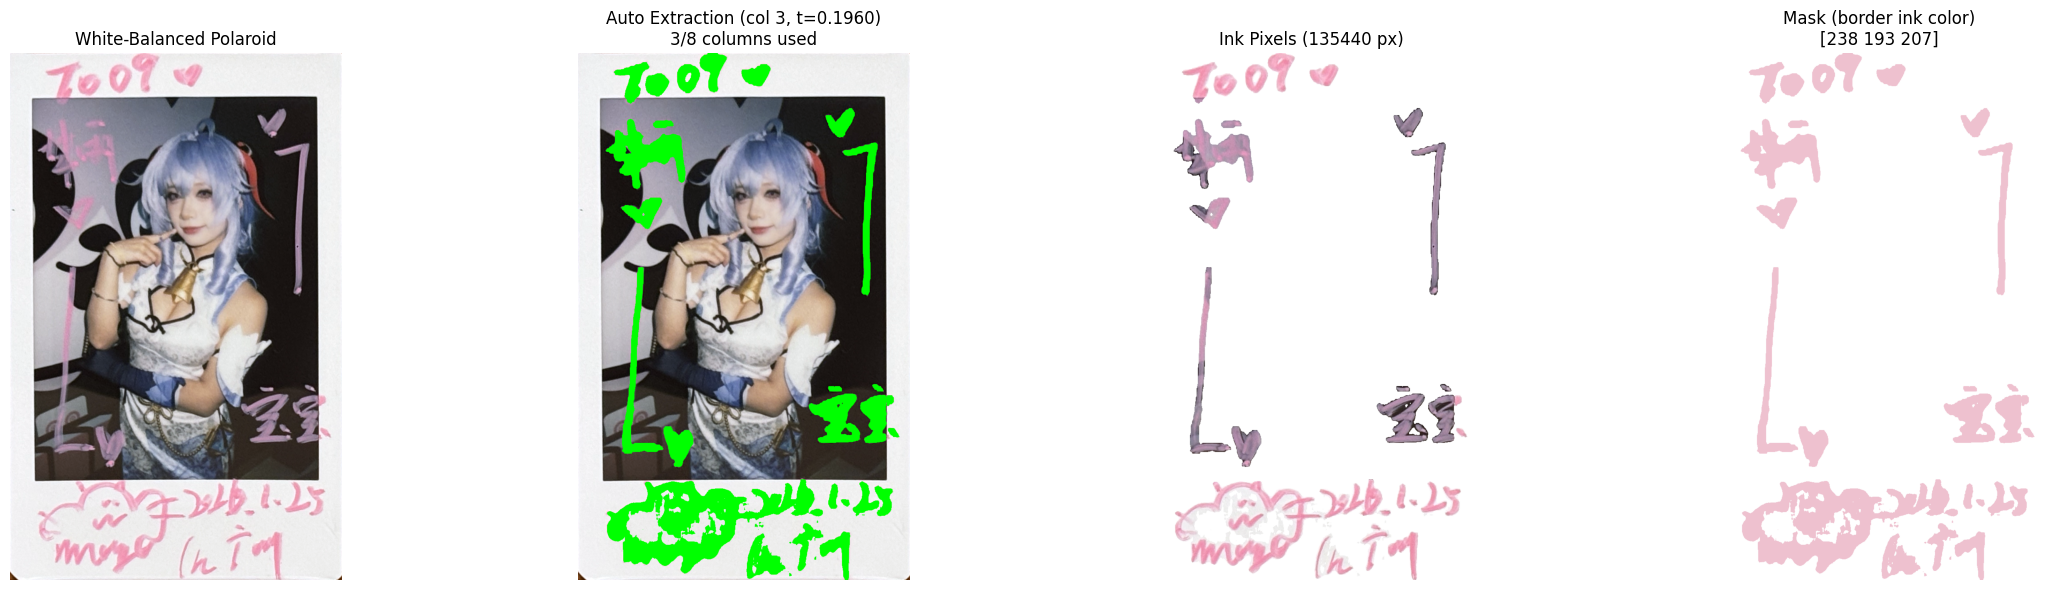


Step   Threshold    n_cur   n_new  n_out   ar_tot     ar_B    mr_B     ar_I    mr_I   Decision
----------------------------------------------------------------------------------------------------
1      0.3160       12509       -      -        -        -       -        -       -       base
2      0.2480      117539  105030      0   89.4%   96.7%    68%   74.0%    94%     accept
3      0.1960      135440   14723   3178   10.9%    0.2%   100%   27.5%    91%     accept
4      0.1560      141495    4098   1957    2.9%    0.0%   100%    6.9%    71%     reject
5      0.1240      142297      29    773    0.0%    0.0%   100%    0.0%    90%     reject
6      0.0960      156470    8076   6097    5.2%    0.0%   100%   11.6%    31%     reject
7      0.0760      159604     948   2186    0.6%    0.1%    98%    1.2%    99%     reject
8      0.0600      159644       0     40    0.0%    0.0%   100%    0.0%   100%     reject
已保存: ink_mask.png


In [30]:
# ===== 6. 自动墨迹提取（scribble prompt + 停止规则） =====
import numpy as np, cv2
from PIL import Image
import torch

# --- 参数 ---
PROBE_THRESHOLDS = [0.5, 0.4, 0.3, 0.2, 0.1]
RATIOS = [0.79, 0.62, 0.49, 0.39, 0.31, 0.24, 0.19, 0.15]
N_STEPS = len(RATIOS)

# 固定图像区域期望顶点 (800×1272)
EXPECTED_AREA = np.array([[55,100],[745,100],[745,1022],[55,1022]], dtype=np.float64)

# 轮廓噪声过滤
OUTLINE_DIST = 20

# --- 后处理开关 ---
# --- 轮廓噪声过滤开关 ---
ENABLE_OUTLINE_RULE = True    # 阈值选取时是否过滤轮廓噪声（影响停止判断）
ENABLE_OUTLINE_MASK = False    # 输出mask时是否去除轮廓噪声
ENABLE_WHITE_REMOVAL = False   # 是否去除接近白色的像素

# --- 停止规则 ---
def stopping_rule(n_cur, ar_t, ar_b, mr_b, ar_i, mr_i):
    """返回 'accept' 或 'reject'"""
    if n_cur > 0 and ar_t < 0.015: return 'reject'
    if (ar_b > 0.15 and (ar_b > 0.50 or mr_b > 0.50)) or (ar_i > 0.15 and (ar_i > 0.50 or mr_i > 0.50)): return 'accept'
    if (ar_b > 0.015 and mr_b < 0.80) or (ar_i > 0.015 and mr_i < 0.80): return 'reject'
    return 'accept'

# --- 构建区域掩码（排除图像边界10px过渡带） ---
H, W = wb_image.shape[:2]
img_area_mask = np.zeros((H, W), dtype=np.uint8)
cv2.fillPoly(img_area_mask, [area_vertices.astype(int)], 1)
img_area_mask = img_area_mask.astype(bool)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
img_dilated = cv2.dilate(img_area_mask.astype(np.uint8), kernel, iterations=1).astype(bool)
img_eroded = cv2.erode(img_area_mask.astype(np.uint8), kernel, iterations=1).astype(bool)
exclude_zone = img_dilated ^ img_eroded          # 20px 过渡带
border_region = ~img_dilated                      # 边框区域
img_region = img_eroded                           # 图像区域

# --- SAM3 scribble 推理（只跑一次） ---
wb_pil = Image.fromarray(wb_image)
inputs = processor(images=wb_pil, text="scribble", return_tensors="pt").to(device)
with torch.no_grad():
    scribble_outputs = model(**inputs)

# --- Probe：找 base threshold ---
base_th = None
for th in PROBE_THRESHOLDS:
    r = processor.post_process_instance_segmentation(
        scribble_outputs, threshold=th, mask_threshold=0.5,
        target_sizes=[wb_pil.size[::-1]]
    )[0]
    if len(r["masks"]) > 0:
        ti = PROBE_THRESHOLDS.index(th)
        base_th = PROBE_THRESHOLDS[ti - 1] if ti > 0 else 0.6338
        break
if base_th is None:
    base_th = 0.1
    print("⚠ 未在任何 probe 阈值检测到墨迹，使用 base=0.1")

print(f"Base threshold: {base_th:.4f}")

# --- 生成所有动态阈值的 mask ---
threshs = [base_th * ratio for ratio in RATIOS]
masks = []
for th in threshs:
    r = processor.post_process_instance_segmentation(
        scribble_outputs, threshold=th, mask_threshold=0.5,
        target_sizes=[wb_pil.size[::-1]]
    )[0]
    if len(r["masks"]) == 0:
        masks.append(np.zeros((H, W), dtype=bool))
    else:
        m = r["masks"].cpu().numpy()
        masks.append(np.any(m, axis=0))

del scribble_outputs, inputs
torch.cuda.empty_cache()

# --- 逐步评估规则，找停止点 ---
steps = []  # 每步的统计数据
stop_idx = N_STEPS  # 默认全部接受
all_outlines = np.zeros((H, W), dtype=bool)  # 累积轮廓噪声

for ti in range(N_STEPS):
    cur_mask = masks[ti]
    n_cur = int(cur_mask.sum())
    
    if ti == 0:
        # base 步：只有当前 mask 信息
        cur_b = int((cur_mask & border_region).sum())
        cur_i = int((cur_mask & img_region).sum())
        steps.append({
            'ti': ti, 'th': threshs[ti], 'is_base': True,
            'n_cur': n_cur, 'n_new': 0, 'area_ratio': 0,
            'n_border_cur': cur_b, 'n_image_cur': cur_i,
            'ar_border': 0, 'mr_border': 1, 'ar_image': 0, 'mr_image': 1,
        })
    else:
        prev_mask = masks[ti - 1]
        new_pixels_raw = cur_mask & ~prev_mask
        n_prev = int(prev_mask.sum())
        
        # --- 轮廓噪声过滤 ---
        if ENABLE_OUTLINE_RULE and n_prev > 0:
            prev_boundary = cv2.Canny((prev_mask & ~exclude_zone).astype(np.uint8) * 255, 0, 1) > 0
            dist = cv2.distanceTransform((~prev_boundary).astype(np.uint8), cv2.DIST_L2, 5)
            outline_pixels = new_pixels_raw & (dist < OUTLINE_DIST)
            n_outline = int(outline_pixels.sum())
            new_pixels = new_pixels_raw & ~outline_pixels
            all_outlines |= outline_pixels  # 累积
        else:
            n_outline = 0
            new_pixels = new_pixels_raw
        n_new = int(new_pixels.sum())
        area_ratio = n_new / n_cur if n_cur > 0 else 0
        
        prev_border = prev_mask & border_region
        prev_image = prev_mask & img_region
        # 面积增量用去除轮廓噪声后的像素
        new_border = new_pixels & border_region
        new_image = new_pixels & img_region
        n_b_new = int(new_border.sum())
        n_i_new = int(new_image.sum())
        # 匹配率用含轮廓噪声的原始像素
        new_border_raw = new_pixels_raw & border_region
        new_image_raw = new_pixels_raw & img_region
        n_b_new_raw = int(new_border_raw.sum())
        n_i_new_raw = int(new_image_raw.sum())
        n_b_prev = int(prev_border.sum())
        n_i_prev = int(prev_image.sum())
        
        # z-score 匹配（边框区域，含轮廓噪声）
        z_b = np.array([])
        if n_b_new_raw > 0 and n_b_prev > 0:
            pb = wb_image[prev_border].astype(float)
            pm, ps = pb.mean(axis=0), pb.std(axis=0)
            nb = wb_image[new_border_raw].astype(float)
            z_b = np.abs((nb - pm) / (ps + 1e-6)).mean(axis=1)
        elif n_b_new_raw > 0:
            z_b = np.zeros(n_b_new_raw)
        
        # z-score 匹配（图像区域，含轮廓噪声）
        z_i = np.array([])
        if n_i_new_raw > 0 and n_i_prev > 0:
            pi_ink = wb_image[prev_image].astype(float)
            pm_i, ps_i = pi_ink.mean(axis=0), pi_ink.std(axis=0)
            ni = wb_image[new_image_raw].astype(float)
            z_i = np.abs((ni - pm_i) / (ps_i + 1e-6)).mean(axis=1)
        elif n_i_new_raw > 0:
            z_i = np.zeros(n_i_new_raw)
        
        # 边框区域指标（面积增量不含轮廓噪声，匹配率含轮廓噪声）
        ar_b = n_b_new / (n_b_prev + n_b_new) if (n_b_prev + n_b_new) > 0 else 0
        m2_b = int((z_b < 2.0).sum()) if len(z_b) > 0 else 0
        mr_b = m2_b / n_b_new_raw if n_b_new_raw > 0 else 1.0
        
        # 图像区域指标
        ar_i = n_i_new / (n_i_prev + n_i_new) if (n_i_prev + n_i_new) > 0 else 0
        m2_i = int((z_i < 2.0).sum()) if len(z_i) > 0 else 0
        mr_i = m2_i / n_i_new_raw if n_i_new_raw > 0 else 1.0
        
        decision = stopping_rule(n_cur, area_ratio, ar_b, mr_b, ar_i, mr_i)
        
        steps.append({
            'ti': ti, 'th': threshs[ti], 'is_base': False,
            'n_cur': n_cur, 'n_new': n_new, 'n_outline': n_outline, 'n_prev': n_prev,
            'area_ratio': area_ratio,
            'n_border_cur': n_b_prev + n_b_new, 'n_image_cur': n_i_prev + n_i_new,
            'ar_border': ar_b, 'mr_border': mr_b, 'ar_image': ar_i, 'mr_image': mr_i,
            'decision': decision,
        })
        
        # 首次碰到 reject → 停止
        if stop_idx == N_STEPS and decision == 'reject':
            stop_idx = ti

# --- 提取结果 ---
if stop_idx == 0:
    ink_mask = masks[0].copy()
    used_ti = 0
    print("⚠ 所有步骤均被拒绝，使用 base mask")
else:
    used_ti = stop_idx - 1
    ink_mask = masks[used_ti].copy()
    print(f"自动停止于第 {stop_idx} 列 (t={threshs[stop_idx]:.4f})，使用第 {used_ti+1} 列 (t={threshs[used_ti]:.4f})")

# 去除累积的轮廓噪声
if ENABLE_OUTLINE_MASK:
    n_outline_total = int((all_outlines & ~exclude_zone).sum())
    ink_mask[all_outlines & ~exclude_zone] = False
    print(f"轮廓噪声去除: {n_outline_total} px (图像边界附近保留)")

# 去除接近白平衡目标 (240,240,240) 的像素（误检的纸面区域）
if ENABLE_WHITE_REMOVAL:
    # 自适应阈值：基于边框墨迹平均颜色，仅移除明显更接近白色的像素
    n_border_ink_cur = int((ink_mask & border_region).sum())
    if n_border_ink_cur > 0:
        border_ink_mean = wb_image[ink_mask & border_region].mean(axis=0)
    else:
        border_ink_mean = np.array([120, 120, 120])
    # 阈值 = 墨迹均值 + 60% 的到白色距离（像素必须所有通道都超过才算白色）
    white_thresh = border_ink_mean + (240 - border_ink_mean) * 0.6
    n_before_w = int(ink_mask.sum())
    white_pixels = ink_mask & np.all(wb_image.astype(float) > white_thresh, axis=2)
    ink_mask[white_pixels] = False
    n_removed_w = n_before_w - int(ink_mask.sum())
    print(f"白色像素去除: {n_removed_w} px (阈值为均值+60%->白)")

# 统计（排除区像素保留在mask中，仅不参与规则计算）
n_ink = int(ink_mask.sum())
n_border_ink = int((ink_mask & border_region).sum())
n_image_ink = int((ink_mask & img_region).sum())
print(f"墨迹像素: 总计 {n_ink} | 边框 {n_border_ink} | 图像 {n_image_ink}")

# --- 可视化 ---
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# 原图
axes[0].imshow(wb_image)
axes[0].set_title('White-Balanced Polaroid')
axes[0].axis('off')

# 墨迹叠加
overlay = wb_image.copy()
overlay[ink_mask] = (0, 255, 0)
axes[1].imshow(overlay)
axes[1].set_title(f'Auto Extraction (col {used_ti+1}, t={threshs[used_ti]:.4f})\n{used_ti+1}/{N_STEPS} columns used')
axes[1].axis('off')

# 墨迹像素（背景色：墨迹近白→黑底，否则白底）
ink_mean = wb_image[ink_mask].mean(axis=0) if ink_mask.any() else np.array([0, 0, 0])
bg_color = 0 if np.all(ink_mean > 200) else 255
ink_pixels = np.full_like(wb_image, bg_color)
ink_pixels[ink_mask] = wb_image[ink_mask]
axes[2].imshow(ink_pixels)
axes[2].set_title(f'Ink Pixels ({n_ink} px)')
axes[2].axis('off')

# 墨迹mask用边框区域墨迹平均颜色填充（白底）
border_ink_mask = ink_mask & border_region
border_ink_color = wb_image[border_ink_mask].mean(axis=0).astype(np.uint8) if border_ink_mask.any() else np.array([60, 60, 60], dtype=np.uint8)
mask_colored = np.full_like(wb_image, 255)  # 白底
mask_colored[ink_mask] = border_ink_color
axes[3].imshow(mask_colored)
axes[3].set_title(f'Mask (border ink color)\n{border_ink_color}')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# --- 打印各步评估 ---
print(f"\n{'Step':<6} {'Threshold':<10} {'n_cur':>7} {'n_new':>7} {'n_out':>6} {'ar_tot':>8} {'ar_B':>8} {'mr_B':>7} {'ar_I':>8} {'mr_I':>7} {'Decision':>10}")
print("-" * 100)
for s in steps:
    if s['is_base']:
        print(f"{s['ti']+1:<6} {s['th']:<10.4f} {s['n_cur']:>7} {'-':>7} {'-':>6} {'-':>8} {'-':>8} {'-':>7} {'-':>8} {'-':>7} {'base':>10}")
    else:
        d = s['decision']
        no = s.get('n_outline', 0)
        print(f"{s['ti']+1:<6} {s['th']:<10.4f} {s['n_cur']:>7} {s['n_new']:>7} {no:>6} {s['area_ratio']:>7.1%} "
              f"{s['ar_border']:>7.1%} {s['mr_border']:>6.0%} {s['ar_image']:>7.1%} {s['mr_image']:>6.0%} {d:>10}")

# 保存墨迹mask供 recover.ipynb 使用
cv2.imwrite("ink_mask.png", (ink_mask.astype(np.uint8) * 255))
print("已保存: ink_mask.png")

In [40]:
# ===== 7. 手动前进到下一个阈值 =====

def advance_threshold():
    """在自动提取结果基础上，前进到下一个（更低）阈值，返回新的墨迹mask"""
    global ink_mask, used_ti
    
    if used_ti >= N_STEPS - 1:
        print(f"已在最后一列 (col {N_STEPS})，无法继续前进")
        return None
    
    used_ti += 1
    ink_mask = masks[used_ti].copy()
    # 后处理
    if ENABLE_OUTLINE_MASK:
        ink_mask[all_outlines] = False
    if ENABLE_WHITE_REMOVAL:
        n_bi = int((ink_mask & border_region).sum())
        bim = wb_image[ink_mask & border_region].mean(axis=0) if n_bi > 0 else np.array([120,120,120])
        wt = bim + (240 - bim) * 0.6
        ink_mask[np.all(wb_image.astype(float) > wt, axis=2)] = False
    
    n_ink = int(ink_mask.sum())
    n_border_ink = int((ink_mask & border_region).sum())
    n_image_ink = int((ink_mask & img_region).sum())
    
    info = steps[used_ti]
    prev_info = steps[used_ti - 1] if used_ti > 0 else None
    
    print(f"▸ 前进到第 {used_ti+1}/{N_STEPS} 列 (t={threshs[used_ti]:.4f})")
    if prev_info:
        delta = n_ink - int(masks[used_ti - 1].sum())
        print(f"  新增像素: {max(0, delta)} | 当前总计: {n_ink} | 边框: {n_border_ink} | 图像: {n_image_ink}")
    if not info['is_base']:
        print(f"  ar_tot={info['area_ratio']:.1%} | "
              f"B: ar={info['ar_border']:.1%} mr={info['mr_border']:.0%} | "
              f"I: ar={info['ar_image']:.1%} mr={info['mr_image']:.0%}")
    
    # 可视化
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(wb_image)
    axes[0].set_title('White-Balanced Polaroid')
    axes[0].axis('off')
    
    overlay = wb_image.copy()
    overlay[ink_mask] = (255, 165, 0)  # 橙色 = 手动前进
    axes[1].imshow(overlay)
    axes[1].set_title(f'Manual Advance → col {used_ti+1} (t={threshs[used_ti]:.4f})')
    axes[1].axis('off')
    
    ink_mean = wb_image[ink_mask].mean(axis=0) if ink_mask.any() else np.array([0, 0, 0])
    bg_color = 0 if np.all(ink_mean > 200) else 255
    ink_pixels = np.full_like(wb_image, bg_color)
    ink_pixels[ink_mask] = wb_image[ink_mask]
    axes[2].imshow(ink_pixels)
    axes[2].set_title(f'Ink Pixels ({n_ink} px)')
    axes[2].axis('off')

    border_ink_mask = ink_mask & border_region
    border_ink_color = wb_image[border_ink_mask].mean(axis=0).astype(np.uint8) if border_ink_mask.any() else np.array([60, 60, 60], dtype=np.uint8)
    mask_colored = np.full_like(wb_image, 255)  # 白底
    mask_colored[ink_mask] = border_ink_color
    axes[3].imshow(mask_colored)
    axes[3].set_title(f'Mask (border ink color)\n{border_ink_color}')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return ink_mask


def retreat_threshold():
    """后退到上一个（更高）阈值，返回新的墨迹mask"""
    global ink_mask, used_ti
    
    if used_ti <= 0:
        print(f"已在第一列 (col 1)，无法继续后退")
        return None
    
    used_ti -= 1
    ink_mask = masks[used_ti].copy()
    # 后处理
    if ENABLE_OUTLINE_MASK:
        ink_mask[all_outlines] = False
    if ENABLE_WHITE_REMOVAL:
        n_bi = int((ink_mask & border_region).sum())
        bim = wb_image[ink_mask & border_region].mean(axis=0) if n_bi > 0 else np.array([120,120,120])
        wt = bim + (240 - bim) * 0.6
        ink_mask[np.all(wb_image.astype(float) > wt, axis=2)] = False
    
    n_ink = int(ink_mask.sum())
    n_border_ink = int((ink_mask & border_region).sum())
    n_image_ink = int((ink_mask & img_region).sum())
    
    info = steps[used_ti]
    next_info = steps[used_ti + 1] if used_ti < N_STEPS - 1 else None
    
    print(f"▹ 后退到第 {used_ti+1}/{N_STEPS} 列 (t={threshs[used_ti]:.4f})")
    if next_info:
        delta = int(masks[used_ti + 1].sum()) - n_ink
        print(f"  减少像素: {delta} | 当前总计: {n_ink} | 边框: {n_border_ink} | 图像: {n_image_ink}")
    if not info['is_base']:
        print(f"  ar_tot={info['area_ratio']:.1%} | "
              f"B: ar={info['ar_border']:.1%} mr={info['mr_border']:.0%} | "
              f"I: ar={info['ar_image']:.1%} mr={info['mr_image']:.0%}")
    
    # 可视化
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(wb_image)
    axes[0].set_title('White-Balanced Polaroid')
    axes[0].axis('off')
    
    overlay = wb_image.copy()
    overlay[ink_mask] = (0, 100, 255)  # 蓝色 = 手动后退
    axes[1].imshow(overlay)
    axes[1].set_title(f'Manual Retreat → col {used_ti+1} (t={threshs[used_ti]:.4f})')
    axes[1].axis('off')
    
    ink_mean = wb_image[ink_mask].mean(axis=0) if ink_mask.any() else np.array([0, 0, 0])
    bg_color = 0 if np.all(ink_mean > 200) else 255
    ink_pixels = np.full_like(wb_image, bg_color)
    ink_pixels[ink_mask] = wb_image[ink_mask]
    axes[2].imshow(ink_pixels)
    axes[2].set_title(f'Ink Pixels ({n_ink} px)')
    axes[2].axis('off')

    border_ink_mask = ink_mask & border_region
    border_ink_color = wb_image[border_ink_mask].mean(axis=0).astype(np.uint8) if border_ink_mask.any() else np.array([60, 60, 60], dtype=np.uint8)
    mask_colored = np.full_like(wb_image, 255)  # 白底
    mask_colored[ink_mask] = border_ink_color
    axes[3].imshow(mask_colored)
    axes[3].set_title(f'Mask (border ink color)\n{border_ink_color}')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return ink_mask


def reset_to_auto():
    """回到自动选取的阈值"""
    global ink_mask, used_ti
    
    if stop_idx == 0:
        used_ti = 0
    else:
        used_ti = stop_idx - 1
    ink_mask = masks[used_ti].copy()
    # 后处理
    if ENABLE_OUTLINE_MASK:
        ink_mask[all_outlines] = False
    if ENABLE_WHITE_REMOVAL:
        n_bi = int((ink_mask & border_region).sum())
        bim = wb_image[ink_mask & border_region].mean(axis=0) if n_bi > 0 else np.array([120,120,120])
        wt = bim + (240 - bim) * 0.6
        ink_mask[np.all(wb_image.astype(float) > wt, axis=2)] = False
    
    n_ink = int(ink_mask.sum())
    n_border_ink = int((ink_mask & border_region).sum())
    n_image_ink = int((ink_mask & img_region).sum())
    print(f"↩ 回到自动选取: 第 {used_ti+1}/{N_STEPS} 列 (t={threshs[used_ti]:.4f}), {n_ink} px")
    
    # 可视化
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(wb_image)
    axes[0].set_title('White-Balanced Polaroid')
    axes[0].axis('off')
    
    overlay = wb_image.copy()
    overlay[ink_mask] = (0, 255, 0)  # 绿色 = 自动
    axes[1].imshow(overlay)
    axes[1].set_title(f'Auto Reset → col {used_ti+1} (t={threshs[used_ti]:.4f})')
    axes[1].axis('off')
    
    ink_mean = wb_image[ink_mask].mean(axis=0) if ink_mask.any() else np.array([0, 0, 0])
    bg_color = 0 if np.all(ink_mean > 200) else 255
    ink_pixels = np.full_like(wb_image, bg_color)
    ink_pixels[ink_mask] = wb_image[ink_mask]
    axes[2].imshow(ink_pixels)
    axes[2].set_title(f'Ink Pixels ({n_ink} px)')
    axes[2].axis('off')
    
    border_ink_mask = ink_mask & border_region
    border_ink_color = wb_image[border_ink_mask].mean(axis=0).astype(np.uint8) if border_ink_mask.any() else np.array([60, 60, 60], dtype=np.uint8)
    mask_colored = np.full_like(wb_image, 255)  # 白底
    mask_colored[ink_mask] = border_ink_color
    axes[3].imshow(mask_colored)
    axes[3].set_title(f'Mask (border ink color)\n{border_ink_color}')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()
    
    return ink_mask


print("命令说明:")
print("  advance_threshold()  — 前进到下一个（更低）阈值")
print("  retreat_threshold()  — 后退到上一个（更高）阈值")
print("  reset_to_auto()      — 回到自动选取的阈值")
print(f"  当前在第 {used_ti+1}/{N_STEPS} 列 (t={threshs[used_ti]:.4f})")


命令说明:
  advance_threshold()  — 前进到下一个（更低）阈值
  retreat_threshold()  — 后退到上一个（更高）阈值
  reset_to_auto()      — 回到自动选取的阈值
  当前在第 3/8 列 (t=0.1960)


In [ ]:
advance_threshold()

In [ ]:
retreat_threshold()

In [ ]:
reset_to_auto()

In [87]:
# ===== 释放 CUDA 显存 =====
import gc

# 清理可能的残留 tensor / 模型输出
for v in ['outputs', 'inputs', 'scribble_outputs', 'paper_vertices_ransac', 'masks', 'all_outlines']:
    if v in dir():
        del globals()[v]

gc.collect()
torch.cuda.empty_cache()
print(f"CUDA 显存已释放，当前分配: {torch.cuda.memory_allocated() / 1024**2:.0f} MB / 缓存: {torch.cuda.memory_reserved() / 1024**2:.0f} MB")

CUDA 显存已释放，当前分配: 3995 MB / 缓存: 4220 MB
